# Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the cleaned dataset
df = pd.read_csv('C:/Users/telvi/Downloads/AMDARI/Nexora_Care_Flow/Data/AppointmentRecords_Cleaned.csv'
)

In [5]:
print(df.shape)

(129353, 16)


In [7]:
df.head()

,AppointmentID,ClinicID,ClinicName,ClinicType,PatientID,ProviderID,AppointmentDateTime,AppointmentType,Status,BookingChannel,BookingLeadTimeDays,IsHoliday,HolidayName,SeasonFlag,ChronicConditionFlag,InvalidLeadTimeFlag
0,529385,2,Nexora Care - Lakeside,Multi-Specialty,103642,202,2024-01-01 08:00:00,New Patient,Completed,Online,2,True,New Year's Day,Flu Season,False,False
1,500000,1,Nexora Care - Riverside,Primary Care,101551,101,2024-01-01 08:30:00,New Patient,No-Show,Online,18,True,New Year's Day,Flu Season,False,False
2,500011,1,Nexora Care - Riverside,Primary Care,100260,104,2024-01-01 08:30:00,Follow-Up,Completed,Referral,4,True,New Year's Day,Flu Season,False,False
3,575066,3,Nexora Care - Downtown Express,Telehealth-Forward,104923,301,2024-01-01 09:45:00,Urgent,Completed,Online,0,True,New Year's Day,Flu Season,False,False
4,500008,1,Nexora Care - Riverside,Primary Care,101124,104,2024-01-01 09:45:00,Telehealth,Completed,Phone,2,True,New Year's Day,Flu Season,False,False


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129353 entries, 0 to 129352
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   AppointmentID         129353 non-null  int64 
 1   ClinicID              129353 non-null  int64 
 2   ClinicName            129353 non-null  object
 3   ClinicType            129353 non-null  object
 4   PatientID             129353 non-null  int64 
 5   ProviderID            129353 non-null  int64 
 6   AppointmentDateTime   129353 non-null  object
 7   AppointmentType       129353 non-null  object
 8   Status                129353 non-null  object
 9   BookingChannel        129353 non-null  object
 10  BookingLeadTimeDays   129353 non-null  int64 
 11  IsHoliday             129353 non-null  bool  
 12  HolidayName           129353 non-null  object
 13  SeasonFlag            129353 non-null  object
 14  ChronicConditionFlag  129353 non-null  bool  
 15  InvalidLeadTimeFl

In [9]:
# CSV files do not preserve pandas datetime types, convert AppointmentDateTime again:
df['AppointmentDateTime'] = pd.to_datetime(
    df['AppointmentDateTime']
)

In [ ]:
#confirm
df['AppointmentDateTime'].dtype

dtype('<M8[ns]')

In [12]:
# Overall Appointment Trend
# Create monthly appointment volumes

monthly_volume = (
    df.set_index('AppointmentDateTime')
      .resample('ME')
      .size()
)

print(monthly_volume)

AppointmentDateTime
2024-01-31    4150
2024-02-29    4153
2024-03-31    3784
2024-04-30    4242
2024-05-31    4113
2024-06-30    3352
2024-07-31    5148
2024-08-31    5362
2024-09-30    4886
2024-10-31    5649
2024-11-30    4745
2024-12-31    6139
2025-01-31    6789
2025-02-28    6188
2025-03-31    6088
2025-04-30    6398
2025-05-31    6099
2025-06-30    5444
2025-07-31    5739
2025-08-31    5971
2025-09-30    6048
2025-10-31    6297
2025-11-30    5374
2025-12-31    7195
Freq: ME, dtype: int64


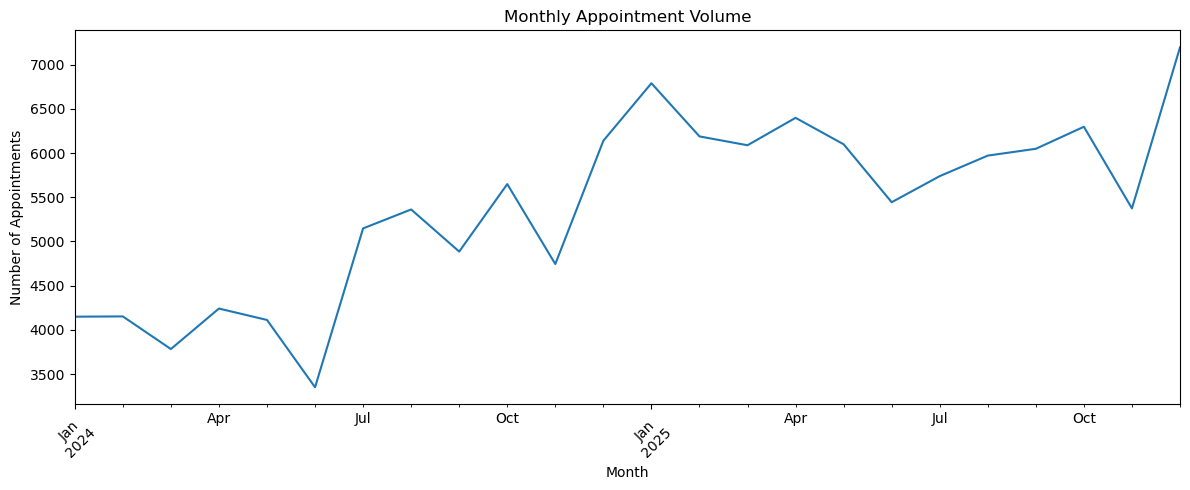

In [13]:
# Plot the trend
plt.figure(figsize=(12, 5))

monthly_volume.plot()

plt.title('Monthly Appointment Volume')
plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Appointment Volume by Clinic
clinic_volume = (
    df.groupby(['ClinicID', 'ClinicName'])
      .size()
      .sort_values(ascending=False)
)

print(clinic_volume)

ClinicID  ClinicName                    
2         Nexora Care - Lakeside            45681
1         Nexora Care - Riverside           29382
4         Nexora Care - Hillcrest           29144
3         Nexora Care - Downtown Express    25146
dtype: int64


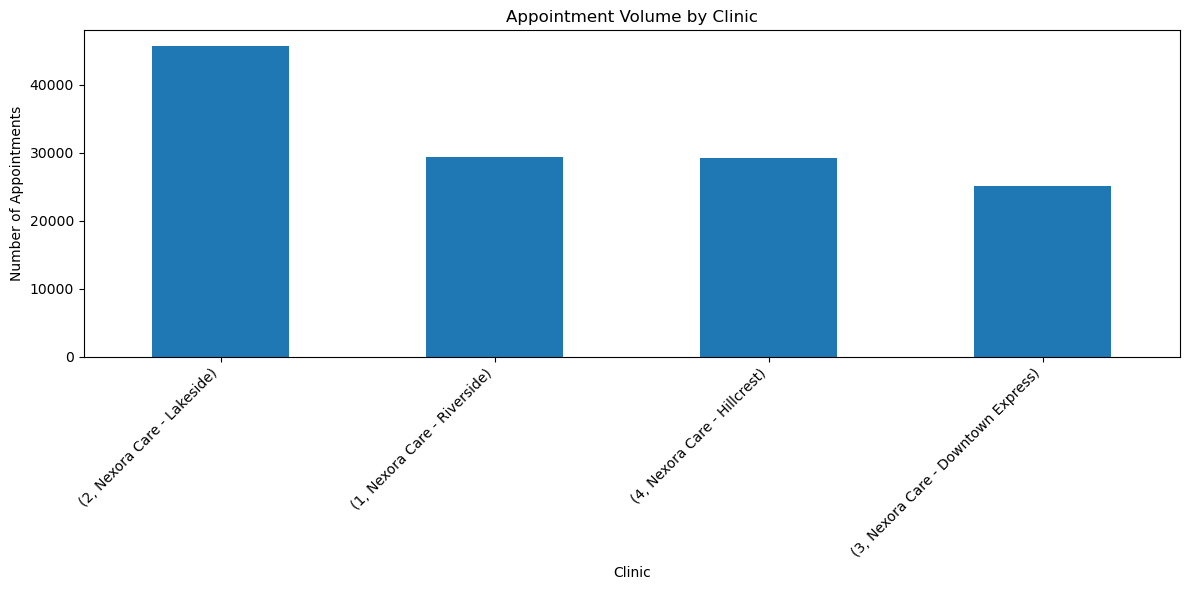

In [16]:
# Visualise the top clinics:
clinic_volume.head(15).plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Appointment Volume by Clinic')
plt.xlabel('Clinic')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [17]:
# Day-of-Week Analysis
# Create the day of the week:
df['DayOfWeek'] = df['AppointmentDateTime'].dt.day_name()

In [18]:
# Set the correct order
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

In [19]:
# Calculate appointment volume
day_volume = (
    df['DayOfWeek']
      .value_counts()
      .reindex(day_order)
)

print(day_volume)

DayOfWeek
Monday       22248
Tuesday      25350
Wednesday    24191
Thursday     22981
Friday       21315
Saturday     11057
Sunday        2211
Name: count, dtype: int64


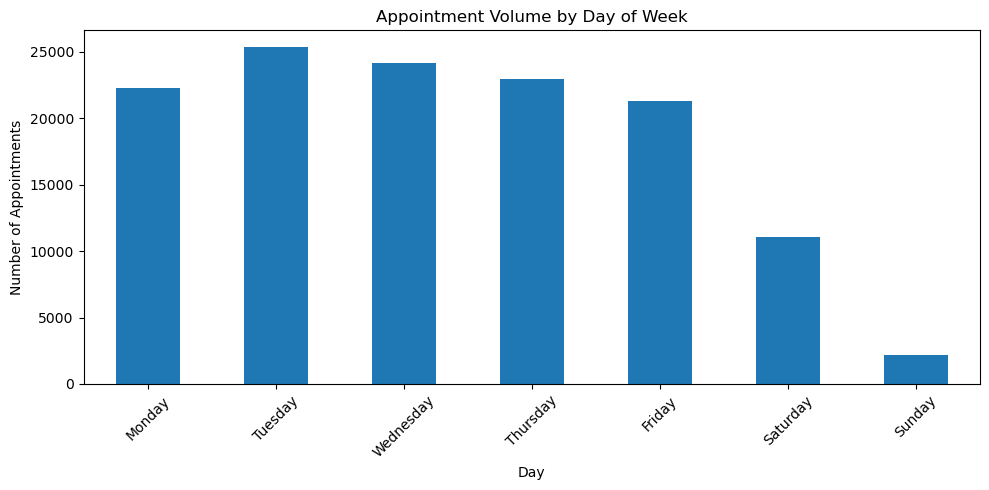

In [20]:
# plot day of the week bar
day_volume.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Appointment Volume by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Day-of-Week Effect by Clinic

# This is particularly important because your requirement says "per clinic."
clinic_day_volume = pd.crosstab(
    df['ClinicName'],
    df['DayOfWeek']
)

clinic_day_volume = clinic_day_volume.reindex(
    columns=day_order
)

print(clinic_day_volume)

DayOfWeek                       Monday  Tuesday  Wednesday  Thursday  Friday  \
ClinicName                                                                     
Nexora Care - Downtown Express    3867     4296       4104      3898    3770   
Nexora Care - Hillcrest           5234     5961       5857      5432    5056   
Nexora Care - Lakeside            7823     9063       8491      8240    7445   
Nexora Care - Riverside           5324     6030       5739      5411    5044   

DayOfWeek                       Saturday  Sunday  
ClinicName                                        
Nexora Care - Downtown Express      3000    2211  
Nexora Care - Hillcrest             1604       0  
Nexora Care - Lakeside              4619       0  
Nexora Care - Riverside             1834       0  


In [ ]:
# Find each clinic's busiest day
# This allows you to identify whether different clinics experience different weekly demand patterns.
busiest_day = clinic_day_volume.idxmax(axis=1)

print(busiest_day)

ClinicName
Nexora Care - Downtown Express    Tuesday
Nexora Care - Hillcrest           Tuesday
Nexora Care - Lakeside            Tuesday
Nexora Care - Riverside           Tuesday
dtype: object


In [23]:
# Seasonal Analysis
# The cleaned data already contains SeasonFlag
season_volume = df['SeasonFlag'].value_counts()

print(season_volume)

SeasonFlag
Standard          64015
Flu Season        34614
Allergy Season    30724
Name: count, dtype: int64


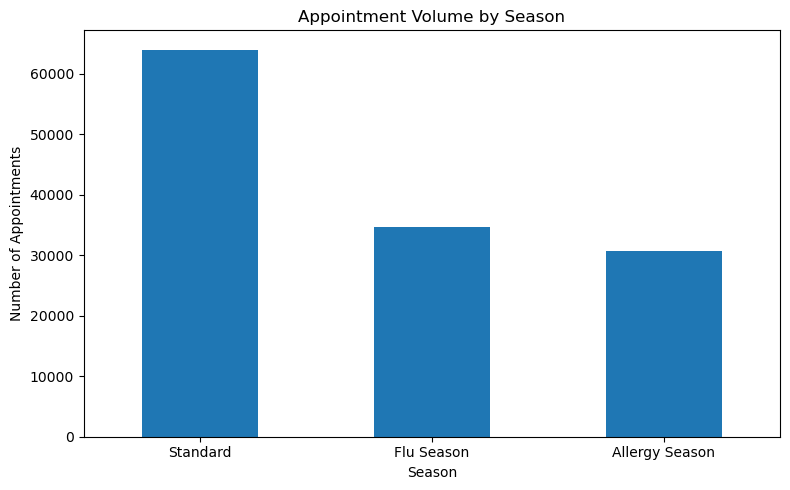

In [24]:
# Plot
season_volume.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Appointment Volume by Season')
plt.xlabel('Season')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
# examine seasons by clinic:
clinic_season = pd.crosstab(
    df['ClinicName'],
    df['SeasonFlag']
)

print(clinic_season)

SeasonFlag                      Allergy Season  Flu Season  Standard
ClinicName                                                          
Nexora Care - Downtown Express            6178        6250     12718
Nexora Care - Hillcrest                   5097        7362     16685
Nexora Care - Lakeside                   11765       12584     21332
Nexora Care - Riverside                   7684        8418     13280


In [26]:
# Holiday Effect

# Our cleaned dataset now contains HolidayName = "No Holiday" where appropriate.
# Compare holiday and non-holiday appointments:
holiday_volume = df['IsHoliday'].value_counts()

print(holiday_volume)

IsHoliday
False    128414
True        939
Name: count, dtype: int64


In [27]:
holiday_summary = (
    df.groupby('IsHoliday')
      .size()
      .rename({
          False: 'Non-Holiday',
          True: 'Holiday'
      })
)

print(holiday_summary)

IsHoliday
Non-Holiday    128414
Holiday           939
dtype: int64


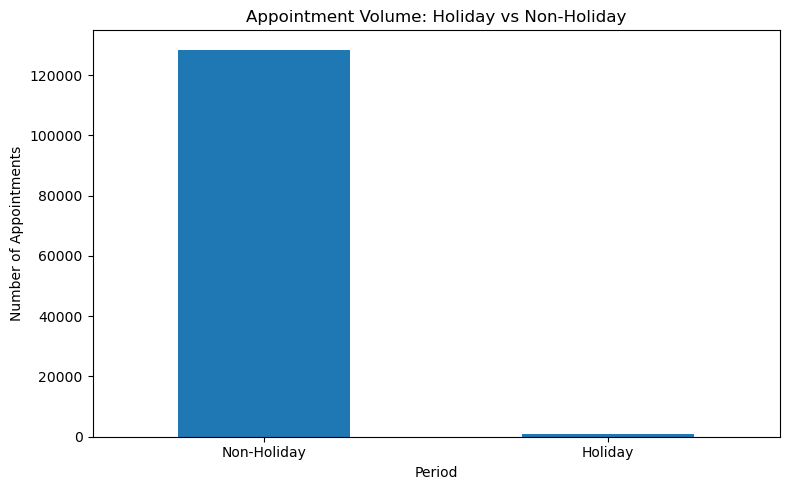

In [28]:
# plot
holiday_summary.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Appointment Volume: Holiday vs Non-Holiday')
plt.xlabel('Period')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
# Appointment Type
appointment_type = df['AppointmentType'].value_counts()

print(appointment_type)

AppointmentType
Follow-Up      57859
Telehealth     30117
New Patient    21583
Urgent         19794
Name: count, dtype: int64


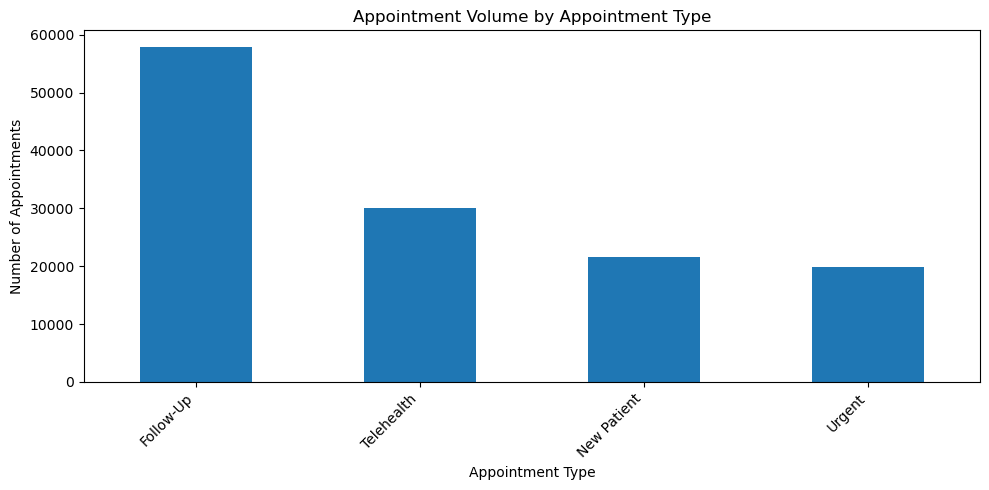

In [30]:
# plot
appointment_type.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Appointment Volume by Appointment Type')
plt.xlabel('Appointment Type')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [31]:
# Booking Channel
booking_channel = df['BookingChannel'].value_counts()

print(booking_channel)

BookingChannel
Online      57061
Phone       39273
Referral    19394
Walk-In     13625
Name: count, dtype: int64


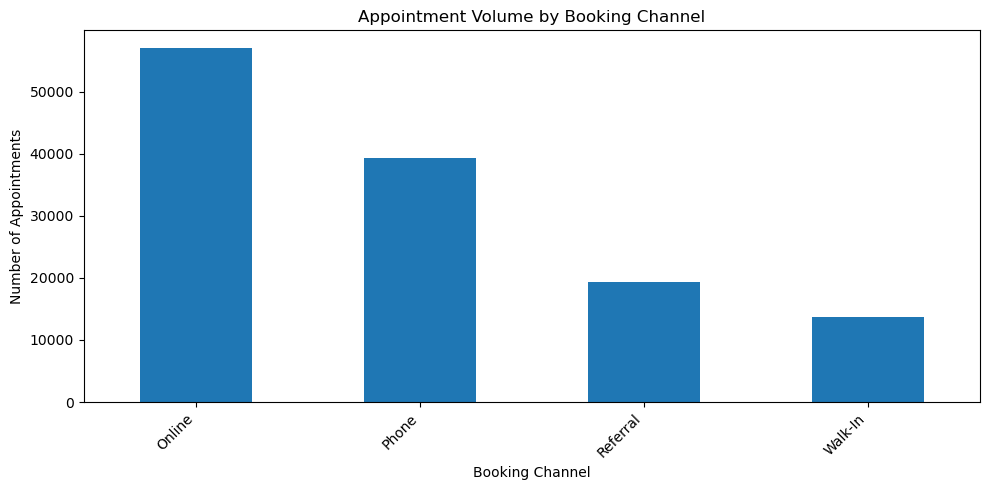

In [32]:
# plot
booking_channel.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Appointment Volume by Booking Channel')
plt.xlabel('Booking Channel')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
# Since BookingLeadTimeDays is potentially useful for forecasting, examine its distribution
df['BookingLeadTimeDays'].describe()

count    129353.000000
mean          8.704267
std           7.641921
min           0.000000
25%           3.000000
50%           7.000000
75%          12.000000
max          60.000000
Name: BookingLeadTimeDays, dtype: float64

In [ ]:
# compare it by appointment type:
lead_time_by_type = (
    df.groupby('AppointmentType')['BookingLeadTimeDays']
      .describe()
)

print(lead_time_by_type)

                   count       mean        std  min  25%   50%   75%   max
AppointmentType                                                           
Follow-Up        57859.0   9.003180   6.338918  0.0  4.0   8.0  12.0  60.0
New Patient      21583.0  14.315016  10.177252  0.0  7.0  12.0  19.0  60.0
Telehealth       30117.0   8.948966   6.348819  0.0  4.0   8.0  12.0  60.0
Urgent           19794.0   1.340356   1.007726  0.0  1.0   1.0   2.0  10.0


In [35]:
status_volume = df['Status'].value_counts()

print(status_volume)

Status
Completed      109040
No-Show         11367
Cancelled        6296
Rescheduled      2650
Name: count, dtype: int64


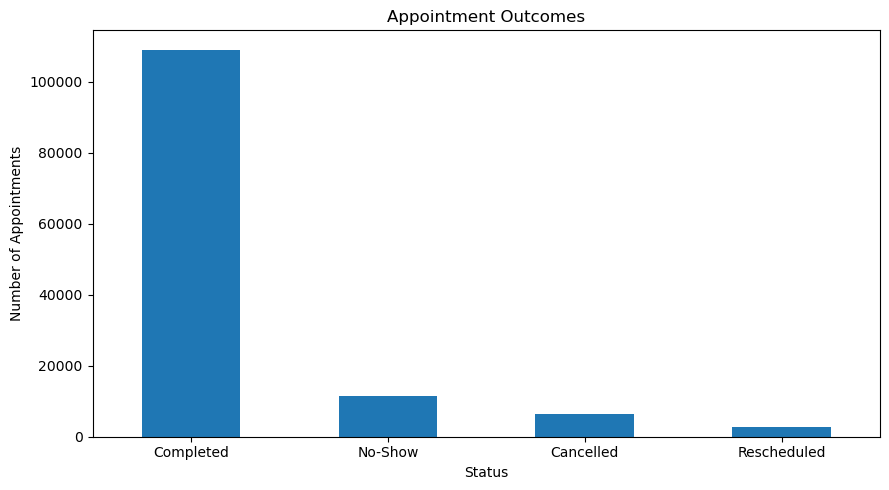

In [36]:
# visualise
status_volume.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Appointment Outcomes')
plt.xlabel('Status')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
# EDA Summary
print("Total appointments:", len(df))

print("\nAppointments by clinic:")
print(df['ClinicName'].value_counts())

print("\nAppointments by day:")
print(df['DayOfWeek'].value_counts().reindex(day_order))

print("\nAppointments by season:")
print(df['SeasonFlag'].value_counts())

print("\nHoliday appointments:")
print(df['IsHoliday'].value_counts())

print("\nAppointment type:")
print(df['AppointmentType'].value_counts())

print("\nBooking channel:")
print(df['BookingChannel'].value_counts())

print("\nAppointment status:")
print(df['Status'].value_counts())

Total appointments: 129353

Appointments by clinic:
ClinicName
Nexora Care - Lakeside            45681
Nexora Care - Riverside           29382
Nexora Care - Hillcrest           29144
Nexora Care - Downtown Express    25146
Name: count, dtype: int64

Appointments by day:
DayOfWeek
Monday       22248
Tuesday      25350
Wednesday    24191
Thursday     22981
Friday       21315
Saturday     11057
Sunday        2211
Name: count, dtype: int64

Appointments by season:
SeasonFlag
Standard          64015
Flu Season        34614
Allergy Season    30724
Name: count, dtype: int64

Holiday appointments:
IsHoliday
False    128414
True        939
Name: count, dtype: int64

Appointment type:
AppointmentType
Follow-Up      57859
Telehealth     30117
New Patient    21583
Urgent         19794
Name: count, dtype: int64

Booking channel:
BookingChannel
Online      57061
Phone       39273
Referral    19394
Walk-In     13625
Name: count, dtype: int64

Appointment status:
Status
Completed      109040
No-Show  